In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q roboflow

import os, json, random
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.4 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128 | Device: cuda


In [6]:
from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

# Change only these 4 lines when you switch dataset
WORKSPACE = "august-4t80o"
PROJECT   = "solar-dust"
VERSION   = 1
FORMAT    = "coco"
api_key = UserSecretsClient().get_secret("roboflow_api_key")
rf = Roboflow(api_key=api_key)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download(FORMAT, location="/kaggle/working/dataset")
print("Downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco in progress : 95.0%
Version export complete for coco format



Extracting Dataset Version Zip to /kaggle/working/dataset in coco:: 100%|██████████| 6760/6760 [00:01<00:00, 5837.71it/s]


Downloaded to: /kaggle/working/dataset


In [7]:
root = dataset.location
found_masks = False

for split in ["train", "valid", "test"]:
    p = os.path.join(root, split, "_annotations.coco.json")
    if not os.path.exists(p):
        print(f"{split}: no COCO json found")
        continue
    d = json.load(open(p))
    n_poly = sum(1 for a in d["annotations"] if a.get("segmentation"))
    found_masks |= n_poly > 0
    print(f"{split}: {len(d['images'])} images | {len(d['annotations'])} annotations | {n_poly} with polygons")
    print("   classes:", [c["name"] for c in d["categories"]])

print("\nU-Net training possible:", found_masks)

train: 5961 images | 9657 annotations | 9657 with polygons
   classes: ['bird-dust-clean-aUfv', 'bird_drop', 'clean', 'dust']
valid: 524 images | 924 annotations | 924 with polygons
   classes: ['bird-dust-clean-aUfv', 'bird_drop', 'clean', 'dust']
test: 270 images | 495 annotations | 495 with polygons
   classes: ['bird-dust-clean-aUfv', 'bird_drop', 'clean', 'dust']

U-Net training possible: True


In [23]:
from PIL import Image, ImageDraw
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import torch.nn as nn

IMG_SIZE = 256
DUST_CLASSES = ["dust"]   # only real dust; 'clean' and 'bird_drop' are NOT part of the mask

class CocoMaskDataset(Dataset):
    def __init__(self, split, augment=False):
        self.dir = os.path.join(root, split)
        d = json.load(open(os.path.join(self.dir, "_annotations.coco.json")))
        names = {c["id"]: c["name"] for c in d["categories"]}
        keep = {i for i, n in names.items() if n in DUST_CLASSES}
        anns = {}
        for a in d["annotations"]:
            if a["category_id"] in keep and a.get("segmentation"):
                anns.setdefault(a["image_id"], []).append(a["segmentation"])

        self.imgs, self.masks = [], []
        for info in tqdm(d["images"], desc=f"caching {split}"):
            img = Image.open(os.path.join(self.dir, info["file_name"])).convert("RGB")
            mask = Image.new("L", (info["width"], info["height"]), 0)
            draw = ImageDraw.Draw(mask)
            for seg in anns.get(info["id"], []):
                if isinstance(seg, list):
                    for poly in seg:
                        if len(poly) >= 6:
                            draw.polygon(poly, fill=255)
            self.imgs.append(np.asarray(img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR), dtype=np.uint8))
            self.masks.append((np.asarray(mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)) > 127).astype(np.uint8))
        self.augment = augment
        has = np.mean([m.any() for m in self.masks])
        print(f"{split}: {len(self.imgs)} images | {has*100:.0f}% have dust | mean dust ratio {np.mean([m.mean() for m in self.masks]):.3f}")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = self.imgs[i].astype(np.float32) / 255.0
        mask = self.masks[i].astype(np.float32)
        if self.augment:
            if random.random() < 0.5: img, mask = img[:, ::-1], mask[:, ::-1]
            if random.random() < 0.5: img, mask = img[::-1], mask[::-1]
            img = np.clip(img * random.uniform(0.8, 1.2), 0, 1)
        img = torch.from_numpy(np.ascontiguousarray(img)).permute(2, 0, 1)
        mask = torch.from_numpy(np.ascontiguousarray(mask)).unsqueeze(0)
        return img, mask

caching train:   0%|          | 0/5961 [00:00<?, ?it/s]

train: 5961 images | 43% have dust | mean dust ratio 0.198


caching valid:   0%|          | 0/524 [00:00<?, ?it/s]

valid: 524 images | 38% have dust | mean dust ratio 0.171


caching test:   0%|          | 0/270 [00:00<?, ?it/s]

test: 270 images | 37% have dust | mean dust ratio 0.157
Train / Val / Test: 5961 524 270


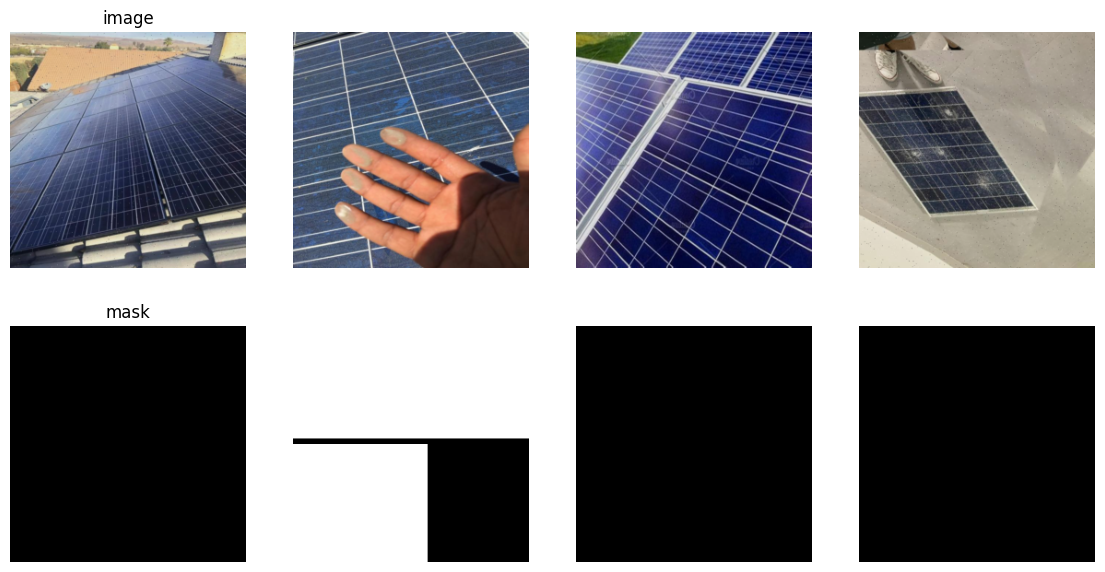

Average dust pixel ratio: 0.183


In [24]:
import matplotlib.pyplot as plt

train_ds = CocoMaskDataset("train", augment=True)
val_ds   = CocoMaskDataset("valid")
test_ds  = CocoMaskDataset("test")

BATCH = 16
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)
print("Train / Val / Test:", len(train_ds), len(val_ds), len(test_ds))

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for k in range(4):
    img, m = train_ds[k]
    ax[0, k].imshow(img.permute(1, 2, 0)); ax[0, k].axis("off")
    ax[1, k].imshow(m[0], cmap="gray");    ax[1, k].axis("off")
ax[0, 0].set_title("image"); ax[1, 0].set_title("mask")
plt.show()

ratio = np.mean([train_ds[k][1].mean().item() for k in range(min(100, len(train_ds)))])
print(f"Average dust pixel ratio: {ratio:.3f}")

In [25]:
class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, f=(32, 64, 128, 256)):
        super().__init__()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        c = in_ch
        for k in f:
            self.downs.append(DoubleConv(c, k)); c = k
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(f[-1], f[-1] * 2)
        for k in reversed(f):
            self.ups.append(nn.ConvTranspose2d(k * 2, k, 2, stride=2))
            self.ups.append(DoubleConv(k * 2, k))
        self.head = nn.Conv2d(f[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for d in self.downs:
            x = d(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            x = self.ups[i + 1](torch.cat([skips[-(i // 2) - 1], x], dim=1))
        return self.head(x)

model = UNet().to(device)
print("Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Output shape:", model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device)).shape)

Parameters: 7,763,041
Output shape: torch.Size([2, 1, 256, 256])


In [30]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, y, eps=1e-6):
    p = torch.sigmoid(logits)
    inter = (p * y).sum((1, 2, 3))
    den = p.sum((1, 2, 3)) + y.sum((1, 2, 3))
    return 1 - ((2 * inter + eps) / (den + eps)).mean()

def loss_fn(logits, y):
    return 0.5 * bce(logits, y) + 0.5 * dice_loss(logits, y)

@torch.no_grad()
def seg_counts(logits, y, thr=0.5):
    pred = (torch.sigmoid(logits) > thr).float()
    tp = (pred * y).sum().item()
    fp = (pred * (1 - y)).sum().item()
    fn = ((1 - pred) * y).sum().item()
    return tp, fp, fn

def scores(tp, fp, fn, eps=1e-9):
    return dict(IoU=tp / (tp + fp + fn + eps), Dice=2 * tp / (2 * tp + fp + fn + eps),
                Precision=tp / (tp + fp + eps), Recall=tp / (tp + fn + eps))

In [31]:
!pip install -q segmentation-models-pytorch onnx onnxruntime

import segmentation_models_pytorch as smp

class WithNorm(nn.Module):
    """ImageNet normalization inside the model, so the data pipeline stays the same."""
    def __init__(self, net, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        super().__init__()
        self.net = net
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return self.net((x - self.mean) / self.std)

def build_models():
    return {
        "UNet_scratch": (UNet(), 1e-3),
        "UNet_ResNet34": (WithNorm(smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1)), 3e-4),
        "DeepLabV3Plus_ResNet34": (WithNorm(smp.DeepLabV3Plus("resnet34", encoder_weights="imagenet", in_channels=3, classes=1)), 3e-4),
    }

for name, (net, lr) in build_models().items():
    print(f"{name}: {sum(p.numel() for p in net.parameters()):,} parameters")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 76.7 MB/s eta 0:00:00:00:0100:01


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

UNet_scratch: 7,763,041 parameters
UNet_ResNet34: 24,436,369 parameters
DeepLabV3Plus_ResNet34: 22,437,457 parameters


In [33]:
import time, json
from tqdm.auto import tqdm

EPOCHS, PATIENCE = 50, 10      # all 50 epochs odanum na PATIENCE = 50
USE_AMP = device == "cuda"
torch.backends.cudnn.benchmark = True

try:
    make_scaler = lambda: torch.amp.GradScaler("cuda", enabled=USE_AMP)
    make_scaler()
except Exception:
    make_scaler = lambda: torch.cuda.amp.GradScaler(enabled=USE_AMP)

def run_epoch(net, dl, opt=None, scaler=None, desc=""):
    train = opt is not None
    net.train(train)
    total, n, tp, fp, fn = 0.0, 0, 0.0, 0.0, 0.0
    for x, y in tqdm(dl, desc=desc, leave=False):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_AMP):
                out = net(x)
            loss = loss_fn(out.float(), y)
        if train:
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
        total += loss.item() * x.size(0); n += x.size(0)
        a, b, c = seg_counts(out.float(), y); tp += a; fp += b; fn += c
    return total / n, scores(tp, fp, fn)

def train_model(name, net, lr):
    net = net.to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    scaler = make_scaler()
    hist = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": [], "epoch_sec": []}
    ckpt = f"/kaggle/working/best_{name}.pth"
    best, best_ep, bad, start = -1.0, 0, 0, time.time()

    for ep in range(1, EPOCHS + 1):
        t0 = time.time()
        tl, _ = run_epoch(net, train_dl, opt, scaler, f"{name} ep{ep} train")
        vl, vs = run_epoch(net, val_dl, desc=f"{name} ep{ep} val")
        sched.step(vs["IoU"])
        sec = time.time() - t0
        for k, v in zip(hist, (tl, vl, vs["IoU"], vs["Dice"], sec)):
            hist[k].append(v)
        print(f"[{name}] Epoch {ep:02d} | train {tl:.4f} | val {vl:.4f} | IoU {vs['IoU']:.4f} | Dice {vs['Dice']:.4f} | {sec:.0f}s")

        if vs["IoU"] > best:
            best, best_ep, bad = vs["IoU"], ep, 0
            torch.save(net.state_dict(), ckpt)
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"[{name}] Early stopping at epoch {ep}"); break

    wall = time.time() - start
    net.load_state_dict(torch.load(ckpt, map_location=device))
    return net, hist, best, best_ep, wall

results = {}
for name, (net, lr) in build_models().items():
    print(f"\n===== Training {name} =====")
    net, hist, best, best_ep, wall = train_model(name, net, lr)
    results[name] = dict(model=net, hist=hist, best_val_iou=best, best_epoch=best_ep, wall_sec=wall)
    print(f"[{name}] best val IoU {best:.4f} at epoch {best_ep} | WALL TIME {wall/60:.1f} min ({wall:.0f} s)")

json.dump({n: {k: v for k, v in r.items() if k != "model"} for n, r in results.items()},
          open("/kaggle/working/training_results.json", "w"))
print("\nTotal wall time (all 3 models):", f"{sum(r['wall_sec'] for r in results.values())/60:.1f} min")


===== Training UNet_scratch =====


UNet_scratch ep1 train:   0%|          | 0/373 [00:00<?, ?it/s]

UNet_scratch ep1 val:   0%|          | 0/33 [00:00<?, ?it/s]

[UNet_scratch] Epoch 01 | train 0.6428 | val 0.6196 | IoU 0.3188 | Dice 0.4835 | 61s


UNet_scratch ep2 train:   0%|          | 0/373 [00:00<?, ?it/s]

...

[DeepLabV3Plus_ResNet34] Epoch 33 | train 0.3183 | val 0.5535 | IoU 0.5962 | Dice 0.7470 | 35s


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7973e2ac5440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7973e2ac5440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

DeepLabV3Plus_ResNet34 ep34 train:   0%|          | 0/373 [00:00<?, ?it/s]

DeepLabV3Plus_ResNet34 ep34 val:   0%|          | 0/33 [00:00<?, ?it/s]

[DeepLabV3Plus_ResNet34] Epoch 34 | train 0.3181 | val 0.5583 | IoU 0.5916 | Dice 0.7434 | 36s
[DeepLabV3Plus_ResNet34] Early stopping at epoch 34
[DeepLabV3Plus_ResNet34] best val IoU 0.6001 at epoch 24 | WALL TIME 24.6 min (1477 s)

Total wall time (all 3 models): 100.2 min


UNet_scratch test:   0%|          | 0/17 [00:00<?, ?it/s]

UNet_ResNet34 test:   0%|          | 0/17 [00:00<?, ?it/s]

DeepLabV3Plus_ResNet34 test:   0%|          | 0/17 [00:00<?, ?it/s]

Model            UNet_scratch  UNet_ResNet34  DeepLabV3Plus_ResNet34
Test IoU               0.5647         0.5705                  0.5880
Test Dice              0.7218         0.7265                  0.7406
Precision              0.7203         0.6935                  0.7188
Recall                 0.7234         0.7629                  0.7636
Best val IoU           0.5383         0.6025                  0.6001
Best epoch            46.0000        10.0000                 24.0000
Epochs run            50.0000        20.0000                 34.0000
Params (M)             7.8000        24.4000                 22.4000
Wall time (min)       55.9000        19.6000                 24.6000
Avg s/epoch           66.5000        51.3000                 41.1000


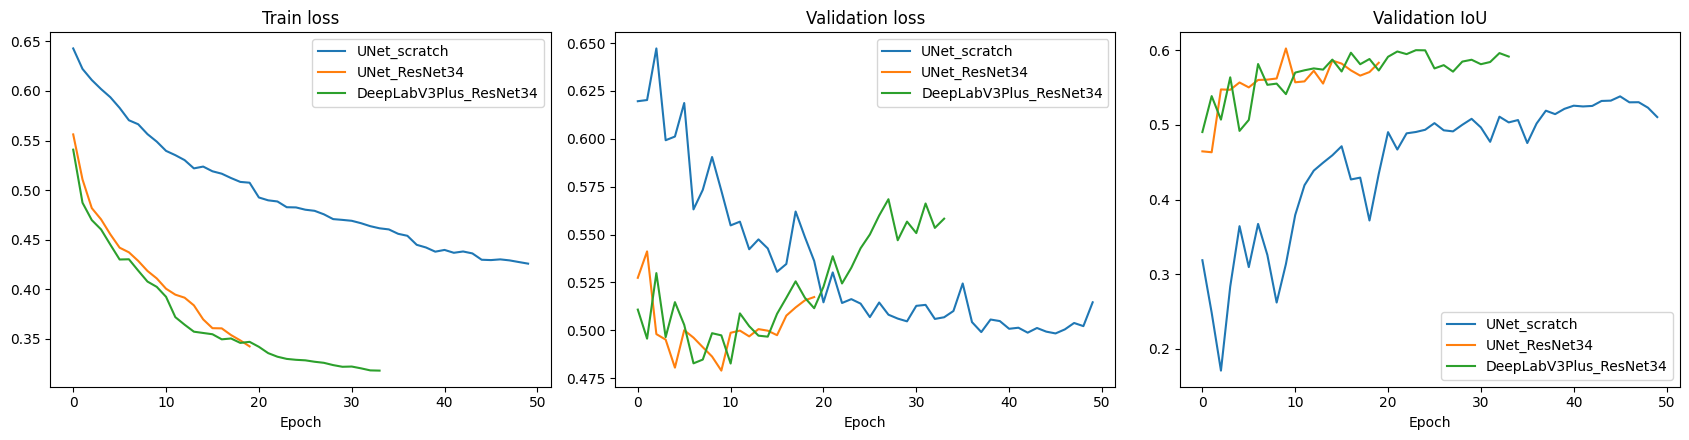

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for name, r in results.items():
    _, ts = run_epoch(r["model"], test_dl, desc=f"{name} test")
    rows.append({"Model": name,
                 "Test IoU": round(ts["IoU"], 4), "Test Dice": round(ts["Dice"], 4),
                 "Precision": round(ts["Precision"], 4), "Recall": round(ts["Recall"], 4),
                 "Best val IoU": round(r["best_val_iou"], 4), "Best epoch": r["best_epoch"],
                 "Epochs run": len(r["hist"]["val_iou"]),
                 "Params (M)": round(sum(p.numel() for p in r["model"].parameters()) / 1e6, 1),
                 "Wall time (min)": round(r["wall_sec"] / 60, 1),
                 "Avg s/epoch": round(float(np.mean(r["hist"]["epoch_sec"])), 1)})
table = pd.DataFrame(rows).set_index("Model")
print(table.T)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for name, r in results.items():
    ax[0].plot(r["hist"]["train_loss"], label=name)
    ax[1].plot(r["hist"]["val_loss"], label=name)
    ax[2].plot(r["hist"]["val_iou"], label=name)
for a, t in zip(ax, ("Train loss", "Validation loss", "Validation IoU")):
    a.set_title(t); a.set_xlabel("Epoch"); a.legend()
plt.tight_layout(); plt.savefig("/kaggle/working/model_comparison.png", dpi=150); plt.show()

from sklearn.metrics import (roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, accuracy_score)

IMG_DIRTY_RATIO = 0.01   # image = "dirty" if >= 1% of its pixels are dust

@torch.no_grad()
def collect(net, dl):
    net.eval(); probs, masks = [], []
    for x, y in dl:
        probs.append(torch.sigmoid(net(x.to(device))).cpu()); masks.append(y)
    return torch.cat(probs), torch.cat(masks)

def full_metrics(net):
    P, M = collect(net, test_dl)

    # pixel level
    pred = (P > 0.5).numpy().ravel().astype(int)
    true = M.numpy().ravel().astype(int)
    tn, fp, fn, tp = confusion_matrix(true, pred, labels=[0, 1]).ravel()
    idx = np.random.default_rng(SEED).choice(true.size, size=min(1_000_000, true.size), replace=False)
    try: auc_px = roc_auc_score(true[idx], P.numpy().ravel()[idx])
    except ValueError: auc_px = float("nan")
    px = dict(Accuracy=(tp + tn) / (tp + tn + fp + fn), Precision=tp / (tp + fp + 1e-9),
              Recall=tp / (tp + fn + 1e-9), F1=2 * tp / (2 * tp + fp + fn + 1e-9),
              IoU=tp / (tp + fp + fn + 1e-9), ROC_AUC=auc_px)

    # image level
    true_ratio = M.mean((1, 2, 3)).numpy()
    pred_ratio = (P > 0.5).float().mean((1, 2, 3)).numpy()
    yt = (true_ratio >= IMG_DIRTY_RATIO).astype(int)
    yp = (pred_ratio >= IMG_DIRTY_RATIO).astype(int)
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
    try: auc_im = roc_auc_score(yt, pred_ratio)
    except ValueError: auc_im = float("nan")
    im = dict(Accuracy=accuracy_score(yt, yp), Precision=p, Recall=r, F1=f, ROC_AUC=auc_im)

    mae = float(np.abs(true_ratio - pred_ratio).mean() * 100)
    return px, im, confusion_matrix(yt, yp, labels=[0, 1]), np.array([[tn, fp], [fn, tp]]), mae

pix_rows, img_rows, cms_px, cms_im = [], [], {}, {}
for name, r in results.items():
    px, im, cm_im, cm_px, mae = full_metrics(r["model"])
    pix_rows.append({"Model": name, **{k: round(float(v), 4) for k, v in px.items()}})
    img_rows.append({"Model": name, **{k: round(float(v), 4) for k, v in im.items()}, "Coverage MAE (%)": round(mae, 2)})
    cms_px[name], cms_im[name] = cm_px, cm_im

print("PIXEL-LEVEL (test set)")
print(pd.DataFrame(pix_rows).set_index("Model"))
print("\nIMAGE-LEVEL, dirty if >= 1% dust (test set)")
print(pd.DataFrame(img_rows).set_index("Model"))

fig, ax = plt.subplots(2, len(results), figsize=(5 * len(results), 9))
ax = np.atleast_2d(ax).reshape(2, -1)
for j, name in enumerate(results):
    c = cms_px[name].astype(float); c = c / c.sum(1, keepdims=True)
    ConfusionMatrixDisplay(c, display_labels=["clean", "dust"]).plot(ax=ax[0, j], colorbar=False, values_format=".2f")
    ax[0, j].set_title(f"{name}\npixel-level (row-normalized)")
    ConfusionMatrixDisplay(cms_im[name], display_labels=["clean", "dirty"]).plot(ax=ax[1, j], colorbar=False, values_format="d")
    ax[1, j].set_title(f"{name}\nimage-level")
plt.tight_layout(); plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150); plt.show()

In [ ]:
best_name = max(results, key=lambda n: results[n]["best_val_iou"])   # chosen on validation, not test
print("Best model (by validation IoU):", best_name)
net = results[best_name]["model"].eval()

idx = [i for i in range(len(test_ds)) if test_ds.masks[i].any()][:6]
fig, ax = plt.subplots(3, len(idx), figsize=(3 * len(idx), 9))
ax = np.atleast_2d(ax).reshape(3, -1)
for k, i in enumerate(idx):
    x, y = test_ds[i]
    with torch.no_grad():
        p = torch.sigmoid(net(x[None].to(device)))[0, 0].cpu().numpy() > 0.5
    img, gt = x.permute(1, 2, 0).numpy(), y[0].numpy() > 0.5
    def over(m):
        o = img.copy(); o[m] = 0.5 * o[m] + 0.5 * np.array([1, 0, 0]); return o
    ax[0, k].imshow(img); ax[1, k].imshow(over(gt)); ax[2, k].imshow(over(p))
    ax[1, k].set_title(f"Ground truth {gt.mean()*100:.1f}%", fontsize=9)
    ax[2, k].set_title(f"Predicted {p.mean()*100:.1f}%", fontsize=9)
    for r in range(3): ax[r, k].axis("off")
plt.suptitle("Row 1: image | Row 2: ground truth | Row 3: prediction")
plt.tight_layout(); plt.savefig("/kaggle/working/predictions.png", dpi=150); plt.show()

# save + ONNX (input: RGB 256x256 float32, pixels/255, NCHW; output: logits)
net_cpu = net.cpu().eval()
torch.save(net_cpu.state_dict(), "/kaggle/working/dust_segmenter.pth")
dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
kw = dict(input_names=["image"], output_names=["logits"],
          dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}}, opset_version=17)
try:
    torch.onnx.export(net_cpu, dummy, "/kaggle/working/dust_segmenter.onnx", dynamo=False, **kw)
except TypeError:
    torch.onnx.export(net_cpu, dummy, "/kaggle/working/dust_segmenter.onnx", **kw)

import onnxruntime as ort
sess = ort.InferenceSession("/kaggle/working/dust_segmenter.onnx")
x, _ = test_ds[idx[0]]
onnx_out = sess.run(None, {"image": x[None].numpy()})[0]
with torch.no_grad():
    torch_out = net_cpu(x[None]).numpy()
print("ONNX vs PyTorch max difference:", float(np.abs(onnx_out - torch_out).max()))
net.to(device)

Best model (by validation IoU): UNet_ResNet34


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for name, r in results.items():
    _, ts = run_epoch(r["model"], test_dl, desc=f"{name} test")
    rows.append({"Model": name,
                 "Test IoU": round(ts["IoU"], 4), "Test Dice": round(ts["Dice"], 4),
                 "Precision": round(ts["Precision"], 4), "Recall": round(ts["Recall"], 4),
                 "Best val IoU": round(r["best_val_iou"], 4), "Best epoch": r["best_epoch"],
                 "Epochs run": len(r["hist"]["val_iou"]),
                 "Params (M)": round(sum(p.numel() for p in r["model"].parameters()) / 1e6, 1),
                 "Wall time (min)": round(r["wall_sec"] / 60, 1),
                 "Avg s/epoch": round(float(np.mean(r["hist"]["epoch_sec"])), 1)})
table = pd.DataFrame(rows).set_index("Model")
print(table.T)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for name, r in results.items():
    ax[0].plot(r["hist"]["train_loss"], label=name)
    ax[1].plot(r["hist"]["val_loss"], label=name)
    ax[2].plot(r["hist"]["val_iou"], label=name)
for a, t in zip(ax, ("Train loss", "Validation loss", "Validation IoU")):
    a.set_title(t); a.set_xlabel("Epoch"); a.legend()
plt.tight_layout(); plt.savefig("/kaggle/working/model_comparison.png", dpi=150); plt.show()